# EE 220 - Homework 1 - Template
## Warm-Up: Circuit Simulation Using NGSPICE
In this homework, we will perform time- and frequency-domain simulations of a wideband RC voltage-divider circuit. Run this notebook to see the results. You will also need to answer questions found in this notebook. This homework also introduces the use of Python notebooks via Google Colab.

Please copy this notebook into your Google drive, and run it from there.

You will then submit this notebook. The submission link and deadline will be posted on our website.


In [1]:
# @title Install schematic libraries

!pip install schemdraw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.5/152.5 kB 2.1 MB/s eta 0:00:00


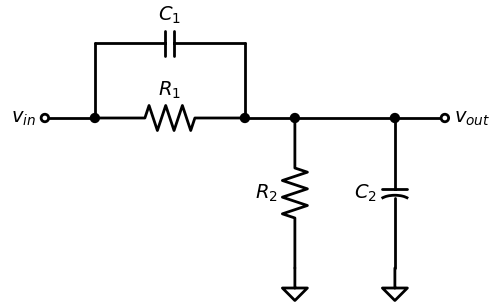

In [2]:
# @title Draw the RC wideband voltage-divider schematic

import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    elm.Dot(open=True).label('$v_{in}$', loc='left')
    elm.Line().right().length(1)
    d.push()
    R1 = elm.Resistor().label('$R_1$')
    d.pop()
    elm.Dot()
    elm.Line().up().length(1.5)
    C1 = elm.Capacitor().right().label('$C_1$')
    elm.Line().down().length(1.5)
    elm.Dot()
    elm.Line().right().length(1)
    d.push()
    R2 = elm.Resistor().down().label('$R_2$')
    elm.GroundSignal()
    d.pop()
    elm.Dot()
    elm.Line().right().length(2)
    d.push()
    C2 = elm.Capacitor2().down().label('$C_2$')
    elm.GroundSignal()
    d.pop()
    elm.Dot()
    elm.Line().right().length(1)
    elm.Dot(open=True).label('$v_{out}$', loc='right')

In [3]:
# @title Install Conda

import os

CONDA_PREFIX = os.environ.get('CONDA_PREFIX', None)

if not CONDA_PREFIX:
  !python -m pip install condacolab
  import condacolab
  condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


# Note:
If the kernel restarts, please re-run the cells below. Select the cell below, then from the menu, click on '**Runtime**' --> '**Run cell and below**'

In [2]:
# @title Setup Conda packages

%%writefile environment.yml
channels:
  - litex-hub
dependencies:
  - ngspice

Overwriting environment.yml


In [3]:
# @title Install Conda packages

!mamba env update -n base -f environment.yml

[+] 0.0s
[+] 0.1s
litex-hub/linux-64..  ⣾  
litex-hub/noarch (..  ⣾  [+] 0.2s
litex-hub/linux-64..  ⣾  
litex-hub/noarch (..  ⣾  [+] 0.3s
litex-hub/linux-64..  ⣾  [+] 0.4s
litex-hub/linux-64..  ⣾  [+] 0.5s
litex-hub/linux-64..  ⣾  [+] 0.6s
litex-hub/linux-64..  ⣾  [+] 0.7s
litex-hub/linux-64..  ⣾  [+] 0.0s
[+] 0.1s
conda-forge/linux-64  ⣾  
conda-forge/noarch    ⣾  
litex-hub/linux-64    ⣾  
litex-hub/noarch      ⣾  [+] 0.2s
conda-forge/linux-64   1%
conda-forge/noarch     3%
litex-hub/linux-64    ⣾  
litex-hub/noarch      ⣾  litex-hub/noarch                                  
[+] 0.3s
conda-forge/linux-64   5%
conda-forge/noarch    23%
litex-hub/linux-64    ⣾  [+] 0.4s
conda-forge/linux-64  12%
conda-forge/noarch    38%
litex-hub/linux-64    ⣾  [+] 0.5s
conda-forge/linux-64  18%
conda-forge/noarch    49%
litex-hub/linux-64    ⣾  [+] 0.6s
conda-forge/linux-64  21%
conda-forge/noarch    57%
litex-hub/linux-64    ⣾  [+] 0.7s
conda-forge/linux-64  23%
conda-forge/noarch    66%
litex-hub/li

In [4]:
# @title Configure NGSPICE
%%writefile .spiceinit
* ngspice initialization for sky130
* assert BSIM compatibility mode with "nf" vs. "W"
set ngbehavior=hsa
* "nomodcheck" speeds up loading time
set ng_nomodcheck
set wr_singlescale

Writing .spiceinit


In [5]:
# @title Create the circuit netlist
%%writefile netlist.spice
* A wideband RC voltage divider circuit

.options savecurrents

R1		in out		900k
R2		out 0		  100k

C1		in out	 	1.1111p
C2		out 0		  10p

* increase C1 and see what happens
R1a		in outa		900k
R2a		outa 0		100k

C1a		in outa	 	1.6p
C2a		outa 0		10p

* decrease C1 and see what happens
R1b		in outb		900k
R2b		outb 0		100k

C1b		in outb	 	0.7p
C2b		outb 0		10p

* input square wave
V1		in 0		  dc 1 ac 1 pulse(-1 1 0 0.1u 0.1u 5u 0.01m)

.control

ac dec 10 1 1G
wrdata output_ac.dat v(out) v(outa) v(outb)

tran 0.01u 0.03m
wrdata output_tran.dat v(out) v(outa) v(outb)

.endc

.end

Writing netlist.spice


In [6]:
# @title Run NGSPICE
!ngspice -b netlist.spice


Note: Compatibility modes selected: hs a


Circuit: * a wideband rc voltage divider circuit

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Note: v1: dc value used for op instead of transient time=0 value.

No. of Data Rows : 91
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Note: v1: dc value used for op instead of transient time=0 value.

Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
in                                          -1
out                                       -0.1
outa                                      -0.1
outb                                      -0.1
v1#branch                                3e-06


No. of Data Rows : 3041
Note: Simulation executed from .control section 


In [7]:
# @title Read in SPICE transient simulation data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_tran = pd.read_csv("output_tran.dat", sep='\\s+', header=None)
df_tran.columns = ["time", "vout", "vouta", "voutb"]
df_tran

,time,vout,vouta,voutb
0,0.000000e+00,-0.1000,-0.100000,-0.100000
1,1.000000e-10,-0.0998,-0.099724,-0.099869
2,2.000000e-10,-0.0996,-0.099448,-0.099738
3,4.000000e-10,-0.0992,-0.098897,-0.099477
4,8.000000e-10,-0.0984,-0.097793,-0.098953
...,...,...,...,...
3036,2.996500e-05,-0.1000,-0.100748,-0.099536
3037,2.997500e-05,-0.1000,-0.100741,-0.099541
3038,2.998500e-05,-0.1000,-0.100734,-0.099546
3039,2.999500e-05,-0.1000,-0.100727,-0.099550


In [8]:
# Create transient voltage results list -- Python loves lists!
v_tran = [ df_tran['vout'], df_tran['vouta'], df_tran['voutb'] ]

# Create plot labels
caps = ["1.1111pF", "1.6pF", "0.7pF"]
v_label = [r"$C_1$ = " + c for c in caps]

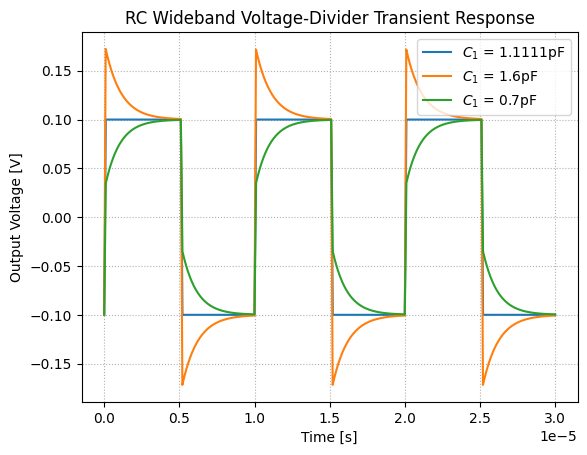

In [9]:
# @title Plot the transient response of the wideband RC voltage-divider

plt.title("RC Wideband Voltage-Divider Transient Response")

for vt,lbl in zip(v_tran,v_label):
  plt.plot(df_tran.time, vt, label=lbl, linestyle='-')

plt.xlabel("Time [s]")
plt.ylabel(r"Output Voltage [V]")
plt.legend(loc='upper right')
plt.grid(linestyle='dotted')
plt.show()

# Question 1:
Where can this circuit be used? This is something you probably have seen before.

Write your answer here:
- It is used in OSCILLOSCOPE PROBE.


In [10]:
# @title Read in SPICE frequency response data

df_ac = pd.read_csv("output_ac.dat", sep='\\s+', header=None)
df_ac.columns = ["freq", "vout_re", "vout_im", "vouta_re", "vouta_im", "voutb_re", "voutb_im"]
df_ac

,freq,vout_re,vout_im,vouta_re,vouta_im,voutb_re,voutb_im
0,1.000000e+00,0.100000,-5.654867e-12,0.100000,2.488141e-07,0.100000,-2.092301e-07
1,1.258925e+00,0.100000,-7.119055e-12,0.100000,3.132384e-07,0.100000,-2.634051e-07
2,1.584893e+00,0.100000,-8.962360e-12,0.100000,3.943438e-07,0.100000,-3.316073e-07
3,1.995262e+00,0.100000,-1.128294e-11,0.100000,4.964495e-07,0.100000,-4.174689e-07
4,2.511886e+00,0.100000,-1.420438e-11,0.100000,6.249929e-07,0.100000,-5.255622e-07
...,...,...,...,...,...,...,...
86,3.981072e+08,0.099999,-3.598019e-10,0.137931,1.452494e-05,0.065421,-1.435528e-05
87,5.011872e+08,0.099999,-2.858008e-10,0.137931,1.153757e-05,0.065421,-1.140281e-05
88,6.309573e+08,0.099999,-2.270197e-10,0.137931,9.164616e-06,0.065421,-9.057571e-06
89,7.943282e+08,0.099999,-1.803281e-10,0.137931,7.279714e-06,0.065421,-7.194685e-06


In [11]:
# @title Calculate the magnitude and phase of the output voltage
# Note the NGSPICE writes the real and imaginary components of the voltage

# Collect all real components in a list
v_real = [ df_ac['vout_re'], df_ac['vouta_re'], df_ac['voutb_re'] ]

# Collect all imaginary components in a list
v_imag = [ df_ac['vout_im'], df_ac['vouta_im'], df_ac['voutb_im'] ]

# Iterate over the lists to get the magnitude and phase of the voltages
v_mag = [ np.sqrt(vr**2 + vi**2) for vr,vi in zip(v_real, v_imag) ]
v_phase = [ np.arctan2(vi, vr) * 180 / np.pi for vr,vi in zip(v_real, v_imag) ]


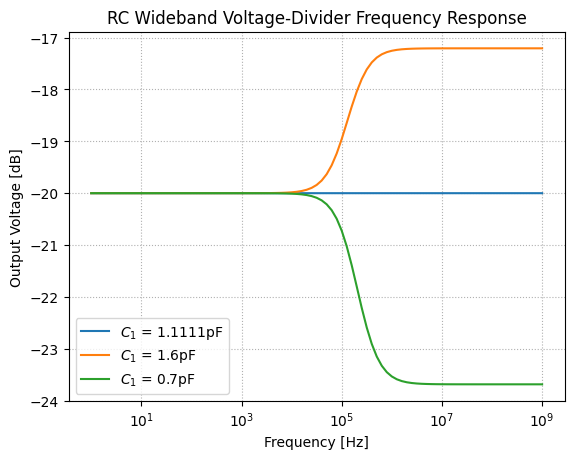

In [12]:
# @title Plot the magnitude frequency response of the wideband RC voltage-divider

plt.title("RC Wideband Voltage-Divider Frequency Response")

for vm,lbl in zip(v_mag,v_label):
  plt.semilogx(df_ac.freq, 20*np.log10(vm), label=lbl, linestyle='-')

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Output Voltage [dB]")
plt.legend(loc='lower left')
plt.grid(linestyle='dotted')
plt.show()

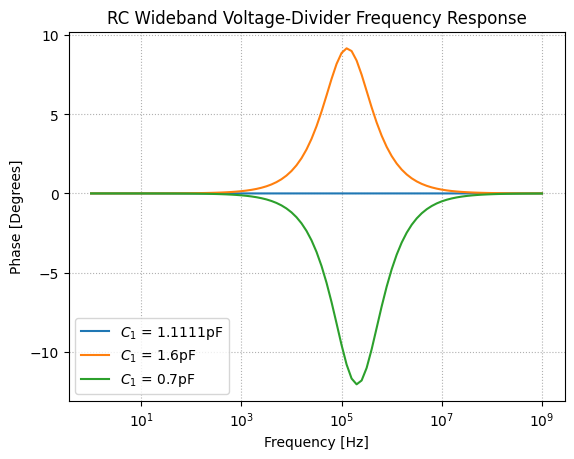

In [13]:
# @title Plot the phase frequency response of the wideband RC voltage-divider

plt.title("RC Wideband Voltage-Divider Frequency Response")

for vp,lbl in zip(v_phase,v_label):
  plt.semilogx(df_ac.freq, vp, label=lbl, linestyle='-')

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"Phase [Degrees]")
plt.legend(loc='lower left')
plt.grid(linestyle='dotted')
plt.show()

# Question 2:
Briefly explain why the frequency response plots (magnitude and phase) behave this way.

Write your answer here:

The frequency response depends on the relationship of the two RC time constant. If C1 = 1.111pF, then R1C1 = R2C2, so the pole and zero compensates each other which produces a constant gain of 0.1 or -20dB and a zero phase shift all over the frequency range.
If C1 = 1.6pF, R1C1 > R2C2, then the high frequency gain becomes larger than the low frequency gain, which produces an increase in the magnitude and a positive phase shift.
If C1 = 0.7pF, R1C1 < R2C2, then there is too little compensation which results in a decrease in magnitude and a negative phase shift.